# Chapter 4 Simple Regression

- run-model4-4.py


In [1]:
import pandas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import arviz
import cmdstanpy

In [2]:
import os

print("Current working directory:", os.getcwd())

Current working directory: /Users/yndk/Desktop/Matsuura/yndk/ch04


In [3]:
os.getcwd()

'/Users/yndk/Desktop/Matsuura/yndk/ch04'

In [4]:
import os, sys

os.chdir('../../chap04')
print("Current working directory:", os.getcwd())

Current working directory: /Users/yndk/Desktop/Matsuura/chap04


In [5]:
d = pandas.read_csv('input/data-salary.csv')
d

,X,Y
0,7,45.7
1,10,48.2
2,16,51.8
3,25,53.5
4,5,42.7
5,25,60.3
6,26,61.0
7,18,48.4
8,17,50.8
9,1,38.0


### Just Run `run-model4-4.py`

In [6]:
from pathlib import Path
stan_file = Path('model', 'model4-4.stan')
stan_code = stan_file.read_text()
print(stan_code)

data {
  int N;
  vector[N] X;
  vector[N] Y;
}

parameters {
  real a;
  real b;
  real<lower=0> sigma;
}

model {
  Y[1:N] ~ normal(a + b*X[1:N], sigma);
}



13:01:02 - cmdstanpy - INFO - compiling stan file /Users/yndk/Desktop/Matsuura/chap04/model/model4-4.stan to exe file /Users/yndk/Desktop/Matsuura/chap04/model/model4-4
13:01:05 - cmdstanpy - INFO - compiled model executable: /Users/yndk/Desktop/Matsuura/chap04/model/model4-4
13:01:06 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

13:01:06 - cmdstanpy - INFO - CmdStan done processing.


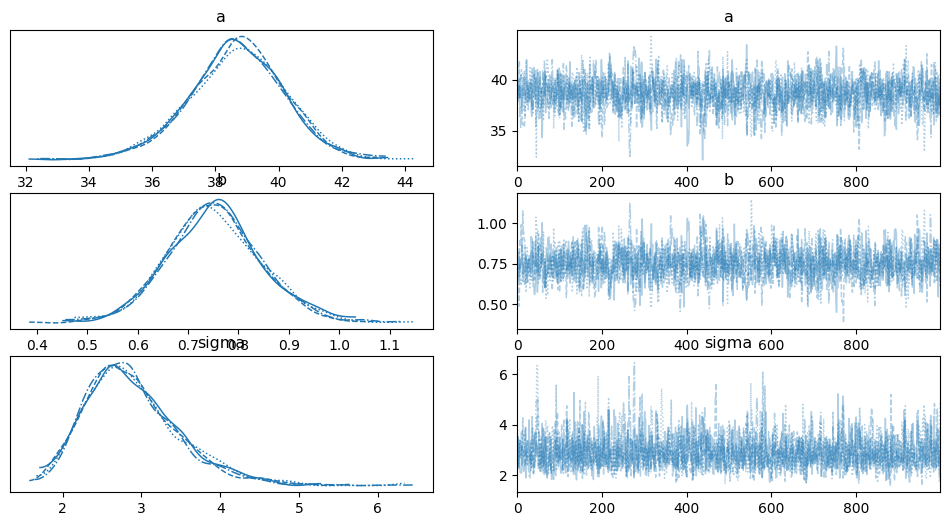

In [7]:
d = pandas.read_csv('input/data-salary.csv')

data = d.to_dict('list')
data.update({'N':len(d)})
model = cmdstanpy.CmdStanModel(stan_file='model/model4-4.stan')
fit = model.sample(data=data, seed=123)

fit.save_csvfiles('output/result-model4-4')
fit.summary().to_csv('output/fit-summary.csv')

axes = arviz.plot_trace(fit)
fig = axes.ravel()[0].figure
fig.savefig('output/fit-plot.pdf')

### Step-by-Step 

In [8]:
d = pandas.read_csv('input/data-salary.csv')
d.describe()

,X,Y
count,15.000000,15.000000
mean,13.933333,49.180000
std,8.455486,6.842117
min,1.000000,38.000000
25%,6.000000,45.300000
50%,16.000000,48.400000
75%,20.000000,52.650000
max,26.000000,61.000000


In [9]:
d.head(4)

,X,Y
0,7,45.7
1,10,48.2
2,16,51.8
3,25,53.5


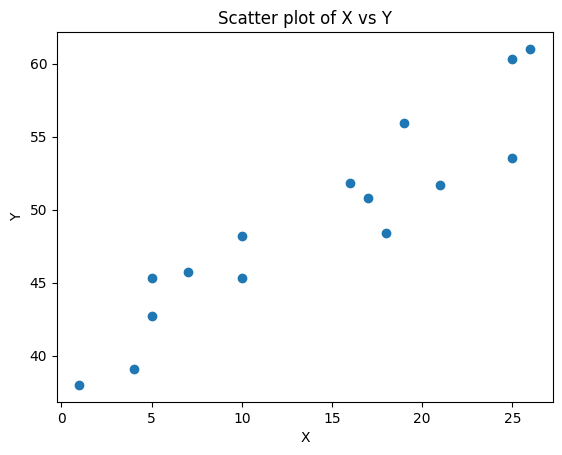

In [10]:
import matplotlib.pyplot as plt

plt.scatter(d.X, d.Y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter plot of X vs Y')
plt.show()

In [11]:
data = d.to_dict('list') # Convert DataFrame to dictionary format 
data.update({'N':len(d)})
data 

{'X': [7, 10, 16, 25, 5, 25, 26, 18, 17, 1, 5, 4, 19, 10, 21],
 'Y': [45.7,
  48.2,
  51.8,
  53.5,
  42.7,
  60.3,
  61.0,
  48.4,
  50.8,
  38.0,
  45.3,
  39.1,
  55.9,
  45.3,
  51.7],
 'N': 15}

In [12]:
with open('model/model4-4.stan', 'r') as f:
    stan_code = f.read()
print("// Stan Model code for model4-4")
print(stan_code)

// Stan Model code for model4-4
data {
  int N;
  vector[N] X;
  vector[N] Y;
}

parameters {
  real a;
  real b;
  real<lower=0> sigma;
}

model {
  Y[1:N] ~ normal(a + b*X[1:N], sigma);
}



In [13]:
# Run the model with the data
model = cmdstanpy.CmdStanModel(stan_file='model/model4-4.stan')

# Sample from the model through HMC-NUTS
fit = model.sample(data=data, seed=123)

13:01:07 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

13:01:07 - cmdstanpy - INFO - CmdStan done processing.


In [14]:
samples_df = fit.draws_pd()
samples_df.describe()

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,a,b,sigma
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.0,4000.000000,4000.000000,4000.000000,4000.000000
mean,2.500000,500.500000,2000.500000,-21.565871,0.919841,0.348902,2.827500,9.11100,0.0,23.053473,38.676544,0.752879,2.901254
std,1.118174,288.711081,1154.844867,1.294082,0.122122,0.047589,0.755239,4.56562,0.0,1.767758,1.520368,0.094024,0.623623
min,1.000000,1.000000,1.000000,-28.237200,0.002324,0.279241,1.000000,1.00000,0.0,20.126948,32.089507,0.383918,1.572285
25%,1.750000,250.750000,1000.750000,-22.162418,0.899066,0.323916,2.000000,7.00000,0.0,21.753896,37.717162,0.692121,2.468449
50%,2.500000,500.500000,2000.500000,-21.256946,0.967281,0.353061,3.000000,7.00000,0.0,22.733774,38.690284,0.749855,2.806933
75%,3.250000,750.250000,3000.250000,-20.612818,0.992828,0.378047,3.000000,15.00000,0.0,24.026834,39.685271,0.810533,3.234978
max,4.000000,1000.000000,4000.000000,-19.932690,1.000000,0.410244,4.000000,27.00000,0.0,31.734791,44.289496,1.148302,6.457590


In [15]:
draws = samples_df[['a', 'b', 'sigma']]
draws.head(4)

,a,b,sigma
0,37.850741,0.770271,2.567508
1,37.880200,0.706214,2.839282
2,39.882005,0.678833,3.528867
3,40.000891,0.651196,2.929441


In [16]:
import plotly.graph_objs as go
import plotly.offline as pyoff

trace = go.Scatter3d(
    x=draws['a'],
    y=draws['b'],
    z=draws['sigma'],
    mode='markers',
    marker=dict(
        size=3,
        color=draws['sigma'],
        colorscale='Viridis',
        opacity=0.7
    )
)

layout = go.Layout(
    scene=dict(
        xaxis_title='a',
        yaxis_title='b',
        zaxis_title='sigma'
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    height=700,
    width=1000,
)

proj_ab = go.Scatter3d(
    x=draws['a'],
    y=draws['b'],
    z=[0] * len(draws),
    mode='markers',
    marker=dict(
        size=2,
        color='rgba(5,5,255,0.5)',
        opacity=0.3
    ),
    showlegend=False
)

layout.height = 700

fig = go.Figure(data=[trace, proj_ab], layout=layout)
pyoff.iplot(fig)

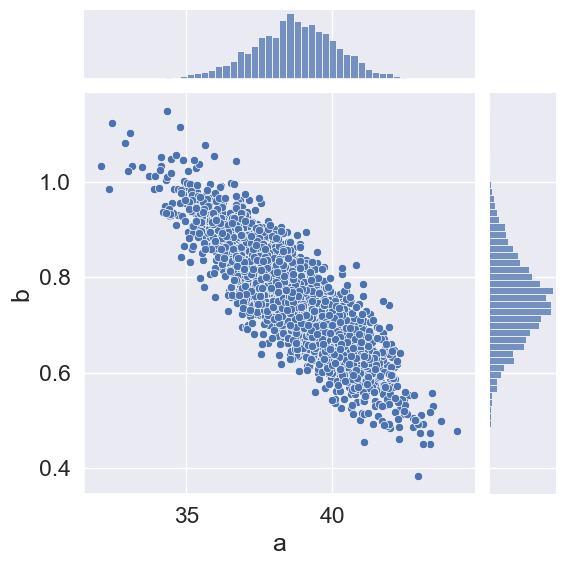

In [17]:
sns.set(font_scale=1.5)
p = sns.jointplot(data=draws, x='a', y='b')

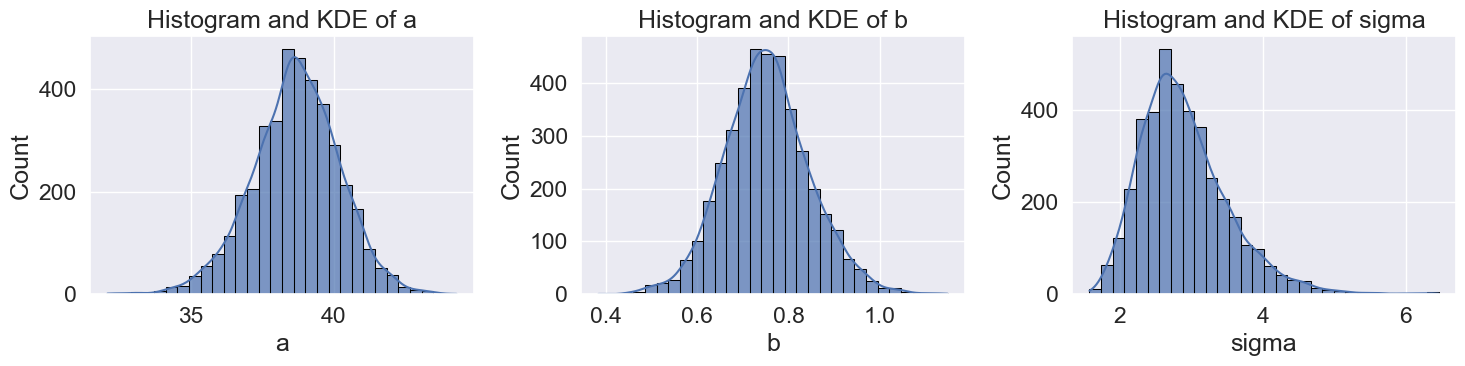

In [18]:
import seaborn as sns

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(draws['a'], bins=30, kde=True, edgecolor='black', alpha=0.7)
plt.xlabel('a')
plt.title('Histogram and KDE of a')

plt.subplot(1, 3, 2)
sns.histplot(draws['b'], bins=30, kde=True, edgecolor='black', alpha=0.7)
plt.xlabel('b')
plt.title('Histogram and KDE of b')

plt.subplot(1, 3, 3)
sns.histplot(draws['sigma'], bins=30, kde=True, edgecolor='black', alpha=0.7)
plt.xlabel('sigma')
plt.title('Histogram and KDE of sigma')

plt.tight_layout()
plt.show()

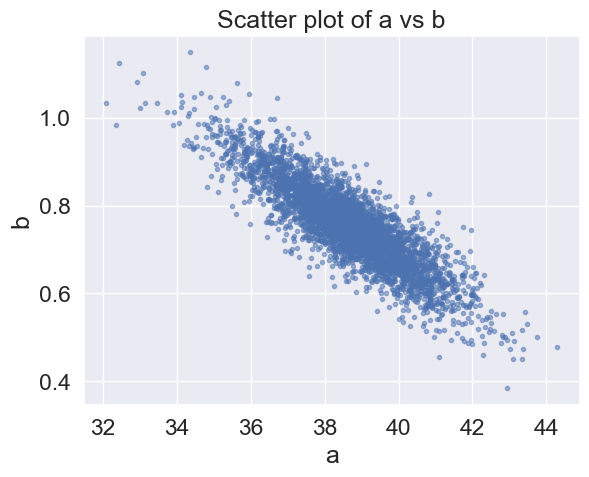

In [19]:
plt.scatter(draws['a'], draws['b'], alpha=0.5, marker='.')
plt.xlabel('a')
plt.ylabel('b')
plt.title('Scatter plot of a vs b')
plt.show()

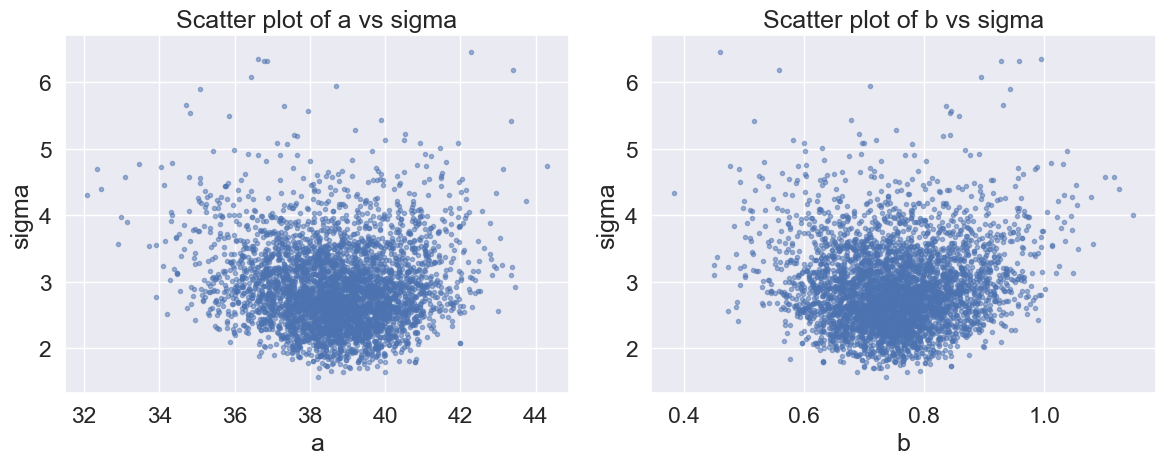

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(draws['a'], draws['sigma'], alpha=0.5, marker='.')
plt.xlabel('a')
plt.ylabel('sigma')
plt.title('Scatter plot of a vs sigma')

plt.subplot(1, 2, 2)
plt.scatter(draws['b'], draws['sigma'], alpha=0.5, marker='.')
plt.xlabel('b')
plt.ylabel('sigma')
plt.title('Scatter plot of b vs sigma')

plt.tight_layout()
plt.show()

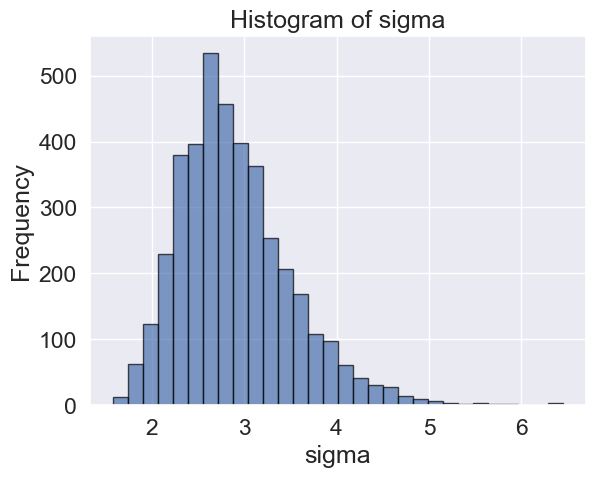

In [21]:
plt.hist(draws['sigma'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('sigma')
plt.ylabel('Frequency')
plt.title('Histogram of sigma')
plt.show()

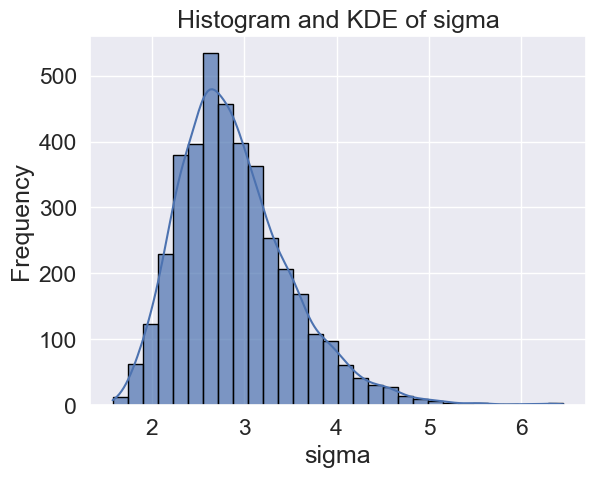

In [22]:
import seaborn as sns

sns.histplot(draws['sigma'], bins=30, kde=True, edgecolor='black', alpha=0.7)
plt.xlabel('sigma')
plt.ylabel('Frequency')
plt.title('Histogram and KDE of sigma')
plt.show()

In [23]:
draws_df = draws.copy()

# compute the mean and standard deviation of 'a', 'b', and 'sigma'
means = draws_df.mean(axis=0)
stds = draws_df.std(axis=0)
print(means['a'], means['b'], means['sigma'], stds['a'], stds['b'], stds['sigma'])
print(means.a, means.b, means.sigma, stds.a, stds.b, stds.sigma)

38.6765439825 0.7528787028424999 2.9012541603 1.520368368136901 0.09402437960508528 0.6236228435620823
38.6765439825 0.7528787028424999 2.9012541603 1.520368368136901 0.09402437960508528 0.6236228435620823


In [24]:
draws_df.head(4)

,a,b,sigma
0,37.850741,0.770271,2.567508
1,37.880200,0.706214,2.839282
2,39.882005,0.678833,3.528867
3,40.000891,0.651196,2.929441


In [25]:
draws_df.mean()

a        38.676544
b         0.752879
sigma     2.901254
dtype: float64

1 26


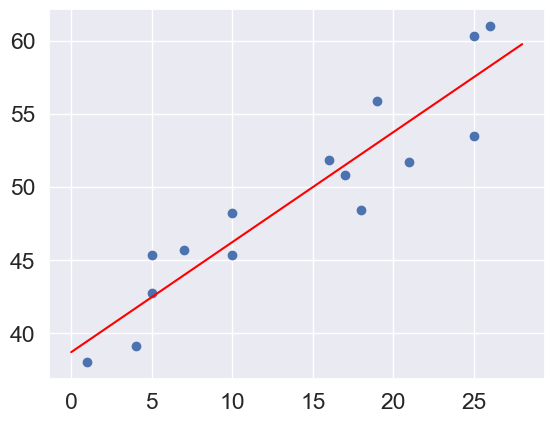

In [26]:
print(d.X.min(), d.X.max())
Xp = np.linspace(d.X.min()-1, d.X.max()+2, 100)

ymean = means['a'] + means['b'] * Xp
plt.plot(Xp, ymean, color='red', label='Mean prediction')
plt.scatter(d.X, d.Y, label='Data points')

1 26


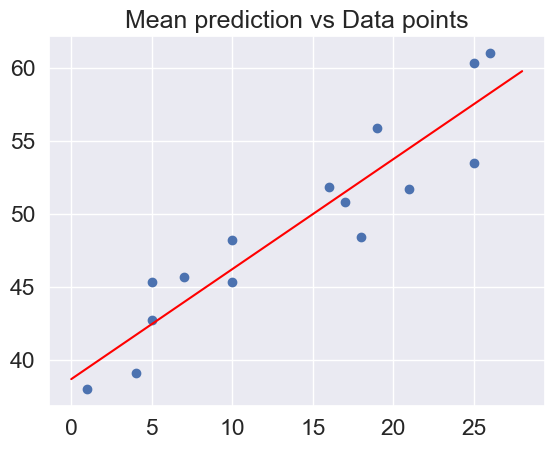

In [27]:
import numpy as np
print(d.X.min(), d.X.max())
Xp = np.linspace(d.X.min()-1, d.X.max()+2, 100)

ymean = means['a'] + means['b'] * Xp

plt.plot(Xp, ymean, color='red', label='Mean prediction')
plt.scatter(d.X, d.Y, label='Data points')
plt.title('Mean prediction vs Data points')
plt.show()

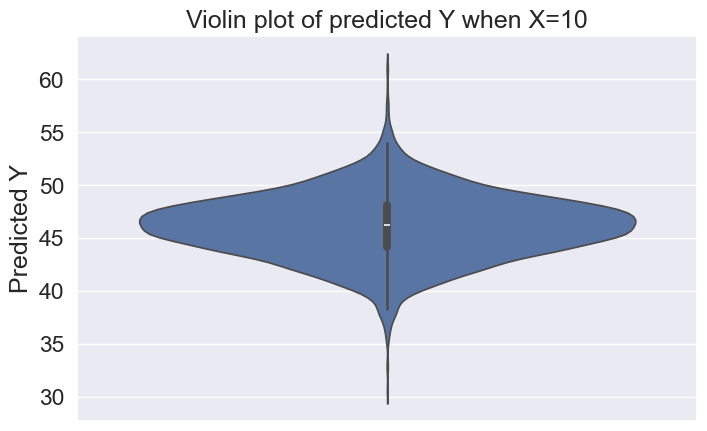

In [28]:
import seaborn as sns

# What would be the predicted value of Y when X=10?
Xpred = 10
Ybase = draws_df['a'] + draws_df['b'] * Xpred
Ypred = Ybase + np.random.normal(0, draws_df['sigma'], size=len(Ybase))

plt.figure(figsize=(8, 5))
sns.violinplot(y=Ypred, inner='box')
plt.ylabel('Predicted Y')
plt.title('Violin plot of predicted Y when X=10')
plt.show()

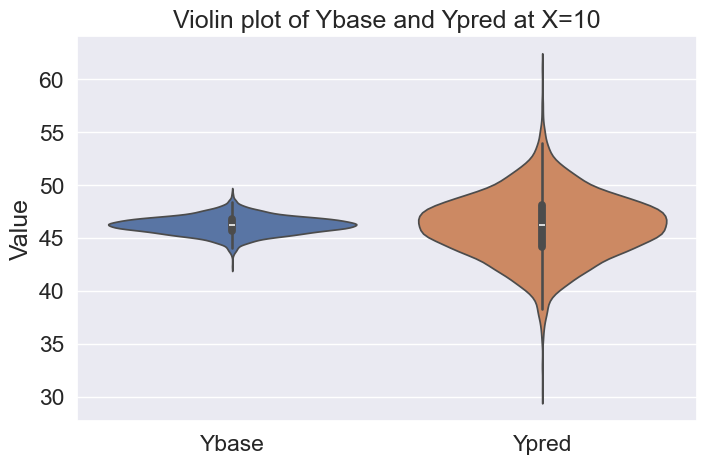

In [29]:
import pandas as pd
import seaborn as sns

df_pred = pd.DataFrame({'Ybase': Ybase, 'Ypred': Ypred})
df_pred.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.grid(True)
sns.violinplot(data=df_pred, inner='box')
plt.ylabel('Value')
plt.title(f'Violin plot of Ybase and Ypred at X={Xpred}')
plt.show()

In [30]:
Xp = np.arange(0, 30)
Np = len(Xp)
N_ms = len(draws_df)

Yb = np.zeros(shape=(N_ms, Np)) # without noise
Yp = np.zeros(shape=(N_ms, Np)) # with noise (sigma)
for n in range(Np):
    Yb[:,n] = draws_df.a + draws_df.b * Xp[n]
    Yp[:,n] = Yb[:,n] + np.random.normal(0, draws_df.sigma, N_ms)

# mean prediction
Ymean = draws_df.a.mean() + draws_df.b.mean() * Xp

# compute quantiles
qua = np.quantile(Yb, [0.025, 0.25, 0.50, 0.75, 0.975], axis=0)

# make a DataFrame for the quantiles
d_est = pandas.DataFrame(np.column_stack([Xp, qua.T]),
                         columns=['X', '2.5%', '25%', '50%', '75%', '97.5%'])

print('Shape of Xp:', Xp.shape)
print('Shape of Yp:', Yp.shape)
print('Shape of Qua:', qua.shape) 
print(d_est.head(2))
print(d_est.tail(2))

Shape of Xp: (30,)
Shape of Yp: (4000, 30)
Shape of Qua: (5, 30)
     X       2.5%        25%        50%        75%      97.5%
0  0.0  35.502985  37.717162  38.690284  39.685271  41.591800
1  1.0  36.421843  38.515581  39.452885  40.393009  42.186151
       X       2.5%        25%        50%        75%      97.5%
28  28.0  56.831668  58.737415  59.740120  60.749103  62.790623
29  29.0  57.416873  59.443412  60.488203  61.553307  63.693001


In [31]:
Yb_df = pandas.DataFrame(Yb, columns=Xp)
print(Yb_df.shape)
print(Yb_df.tail(2))

(4000, 30)
             0          1          2          3          4          5   \
3998  37.629254  38.463132  39.297010  40.130888  40.964766  41.798644   
3999  37.723903  38.524586  39.325268  40.125951  40.926634  41.727316   

             6          7          8          9   ...         20         21  \
3998  42.632522  43.466400  44.300278  45.134156  ...  54.306814  55.140692   
3999  42.527999  43.328682  44.129364  44.930047  ...  53.737556  54.538239   

             22         23         24         25         26         27  \
3998  55.974570  56.808448  57.642326  58.476204  59.310082  60.143960   
3999  55.338921  56.139604  56.940287  57.740969  58.541652  59.342335   

             28         29  
3998  60.977838  61.811716  
3999  60.143017  60.943700  

[2 rows x 30 columns]


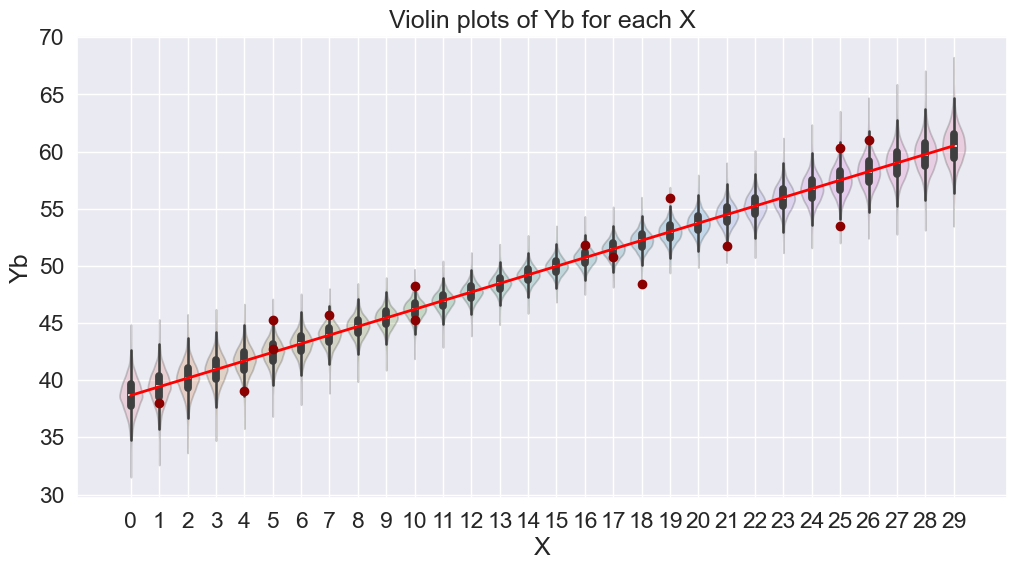

In [32]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(data=Yb_df, inner='box', alpha=.25)
plt.plot(Xp, Ymean, color='red', label='Base prediction', linewidth=2)
plt.scatter(d.X, d.Y, color='darkred', label='Data points', zorder=10)
plt.xlabel('X')
plt.ylabel('Yb')
plt.grid(True)
plt.title('Violin plots of Yb for each X')

plt.show()

In [33]:
print('Density Summary: :', d_est.shape)
print(d_est.head(2))

Density Summary: : (30, 6)
     X       2.5%        25%        50%        75%      97.5%
0  0.0  35.502985  37.717162  38.690284  39.685271  41.591800
1  1.0  36.421843  38.515581  39.452885  40.393009  42.186151


### Bayesian CI for baseline annual income
- Fig. 4.8 (in page 61)
- from 0 to 28 years of work experience
- For each X, CI is computed. The plot is a connection of those CIs.
- No measurement noise first.

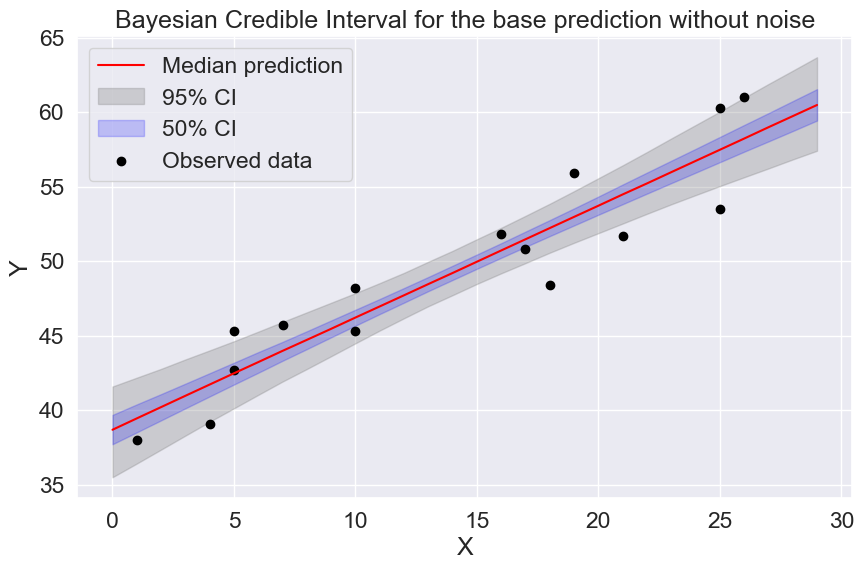

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(d_est['X'], d_est['50%'], color='red', label='Median prediction')
plt.fill_between(d_est['X'], d_est['2.5%'], d_est['97.5%'], color='gray', alpha=0.3, label='95% CI')
plt.fill_between(d_est['X'], d_est['25%'], d_est['75%'], color='blue', alpha=0.2, label='50% CI')
plt.scatter(d.X, d.Y, color='black', label='Observed data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bayesian Credible Interval for the base prediction without noise')
plt.legend()
plt.grid(True)
plt.show()

### Now with measurement noise
- See Fig. 4.8

In [35]:
Yb = np.zeros(shape=(N_ms, Np)) # without noise
Yp = np.zeros(shape=(N_ms, Np)) # with noise (sigma)
for n in range(Np):
    Yb[:,n] = draws_df.a + draws_df.b * Xp[n]
    Yp[:,n] = Yb[:,n] + np.random.normal(0, draws_df.sigma, N_ms)

# compute quantiles for the predictions with measurement noise

qua = np.quantile(Yp, [0.025, 0.25, 0.50, 0.75, 0.975], axis=0)

# make a DataFrame for the quantiles
d_est = pandas.DataFrame(np.column_stack([Xp, qua.T]),
                         columns=['X', '2.5%', '25%', '50%', '75%', '97.5%'])

print('Shape of Xp:', Xp.shape)
print('Shape of Yp:', Yp.shape)
print('Shape of Qua:', qua.shape) 
print(d_est.head(2))
print(d_est.tail(2))

Shape of Xp: (30,)
Shape of Yp: (4000, 30)
Shape of Qua: (5, 30)
     X       2.5%        25%        50%        75%      97.5%
0  0.0  32.145091  36.450703  38.598591  40.737105  45.056021
1  1.0  32.602898  37.341859  39.415987  41.604892  46.020927
       X       2.5%        25%        50%        75%      97.5%
28  28.0  53.112123  57.570936  59.791870  61.890614  66.366625
29  29.0  53.879075  58.360681  60.465013  62.565044  67.324459


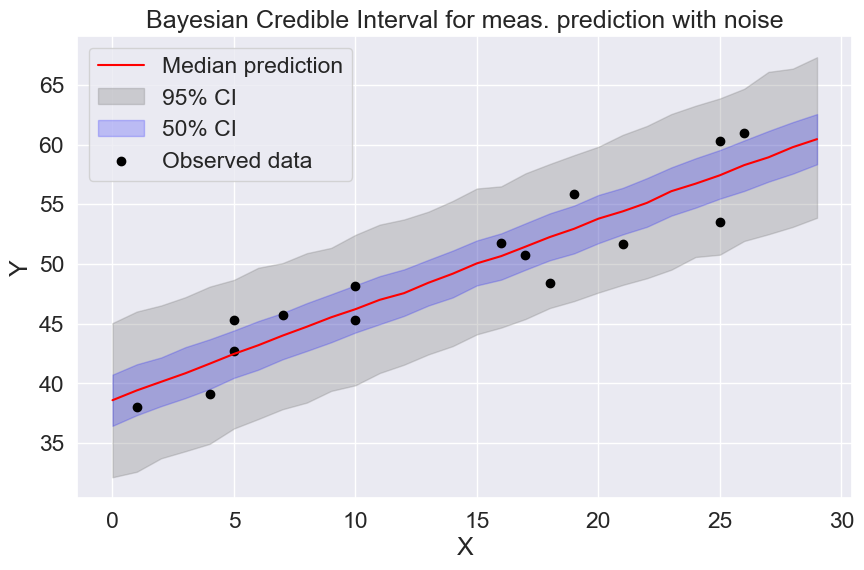

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(d_est['X'], d_est['50%'], color='red', label='Median prediction')
plt.fill_between(d_est['X'], d_est['2.5%'], d_est['97.5%'], color='gray', alpha=0.3, label='95% CI')
plt.fill_between(d_est['X'], d_est['25%'], d_est['75%'], color='blue', alpha=0.2, label='50% CI')
plt.scatter(d.X, d.Y, color='black', label='Observed data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bayesian Credible Interval for meas. prediction with noise')
plt.legend()
plt.grid(True)
plt.show()

## MAP Estimation (Point estimate)

In [37]:
print(stan_code)

data {
  int N;
  vector[N] X;
  vector[N] Y;
}

parameters {
  real a;
  real b;
  real<lower=0> sigma;
}

model {
  Y[1:N] ~ normal(a + b*X[1:N], sigma);
}



In [38]:
map_est = model.optimize(data=data, seed=123)
print('optimization results:')
print(map_est.a, map_est.b, map_est.sigma)

# pandas output
map_est_pd = map_est.optimized_params_pd
map_est_dict = map_est.optimized_params_dict
map_est.optimized_params_pd, map_est.optimized_params_dict, map_est.optimized_params_np

13:01:09 - cmdstanpy - INFO - Chain [1] start processing
13:01:09 - cmdstanpy - INFO - Chain [1] done processing
13:01:09 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
13:01:09 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
13:01:09 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.


optimization results:
38.696927 0.75237698 2.4331812


(        lp__          a         b     sigma
 0 -20.837806  38.696927  0.752377  2.433181,
 OrderedDict([('lp__', np.float64(-20.837806)),
              ('a', np.float64(38.696927)),
              ('b', np.float64(0.75237698)),
              ('sigma', np.float64(2.4331812))]),
 array([-20.837806  ,  38.696927  ,   0.75237698,   2.4331812 ]))

In [39]:
map_est_dict['a']

np.float64(38.696927)

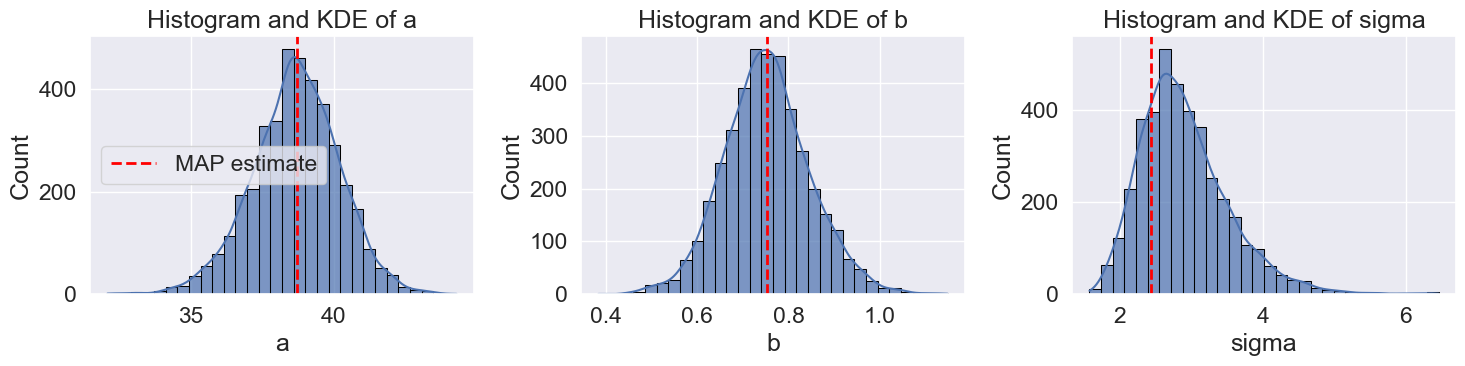

In [40]:
import seaborn as sns

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(draws['a'], bins=30, kde=True, edgecolor='black', alpha=0.7)
plt.axvline(x=map_est_dict['a'], color='red', linestyle='--', linewidth=2, label='MAP estimate')
plt.legend()
plt.xlabel('a')
plt.title('Histogram and KDE of a')

plt.subplot(1, 3, 2)
sns.histplot(draws['b'], bins=30, kde=True, edgecolor='black', alpha=0.7)
plt.axvline(x=map_est_dict['b'], color='red', linestyle='--', linewidth=2, label='MAP estimate')
plt.xlabel('b')
plt.title('Histogram and KDE of b')

plt.subplot(1, 3, 3)
sns.histplot(draws['sigma'], bins=30, kde=True, edgecolor='black', alpha=0.7)
plt.axvline(x=map_est_dict['sigma'], color='red', linestyle='--', linewidth=2, label='MAP estimate')
plt.xlabel('sigma')
plt.title('Histogram and KDE of sigma')

plt.tight_layout()
plt.show()

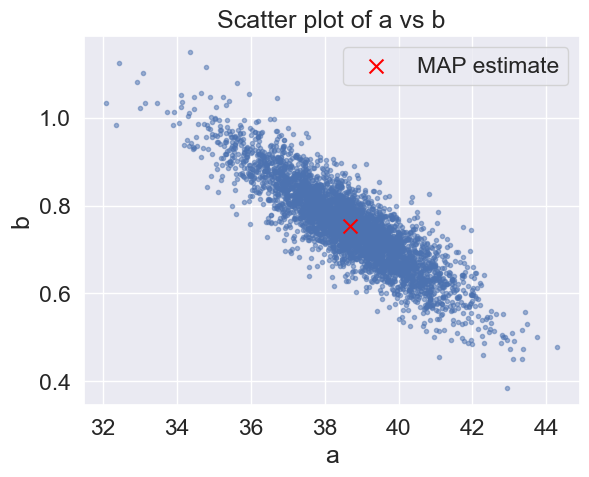

In [41]:
plt.scatter(draws['a'], draws['b'], alpha=0.5, marker='.')
plt.scatter(map_est_dict['a'], map_est_dict['b'], color='red', marker='x', s=100, label='MAP estimate')
plt.legend()
plt.xlabel('a')
plt.ylabel('b')
plt.title('Scatter plot of a vs b')
plt.show()

## 🧠 Joint vs Marginal Modes: What's the Difference?

In general, **yes**, the mode of the marginal posterior $p(a)$ can be **different** from the value of $a$ at the mode of the joint posterior $p(a, b, c)$. Here's why:

### 🔍 Definitions

- **Joint mode**: The point $(a^*, b^*, c^*)$ that maximizes the joint posterior $p(a, b, c)$.
- **Marginal mode**: The value $a^\dagger$ that maximizes the marginal posterior  
  $$
  p(a) = \int \int p(a, b, c) \, db \, dc
  $$

### 📉 Why They Differ

- **Integration vs Optimization**: Marginalization involves integrating out $b$ and $c$, which can shift the peak of $p(a)$ away from $a^*$.
- **Skewness and Correlation**: If $a$ is correlated with $b$ or $c$, or if the joint distribution is skewed, the marginal distribution may peak at a different value.
- **Dimensionality Effects**: In higher dimensions, the volume around the joint mode may not contribute the most to the marginal density.

### 🧪 Example

Imagine a bivariate distribution $p(a, b)$ shaped like a tilted ellipse.  
- The **joint mode** might be at the tip of the ellipse.  
- The **marginal mode** of $a$ could be somewhere along the longer axis—where the density is spread out more.

### 🧭 Practical Implication

If you're interested in inference for $a$ alone, it's better to use the **marginal posterior** $p(a)$ rather than relying on the joint mode. This is especially true in Bayesian modeling where uncertainty and dependencies matter.

---

Want to see a visual or code example to make this even more intuitive?

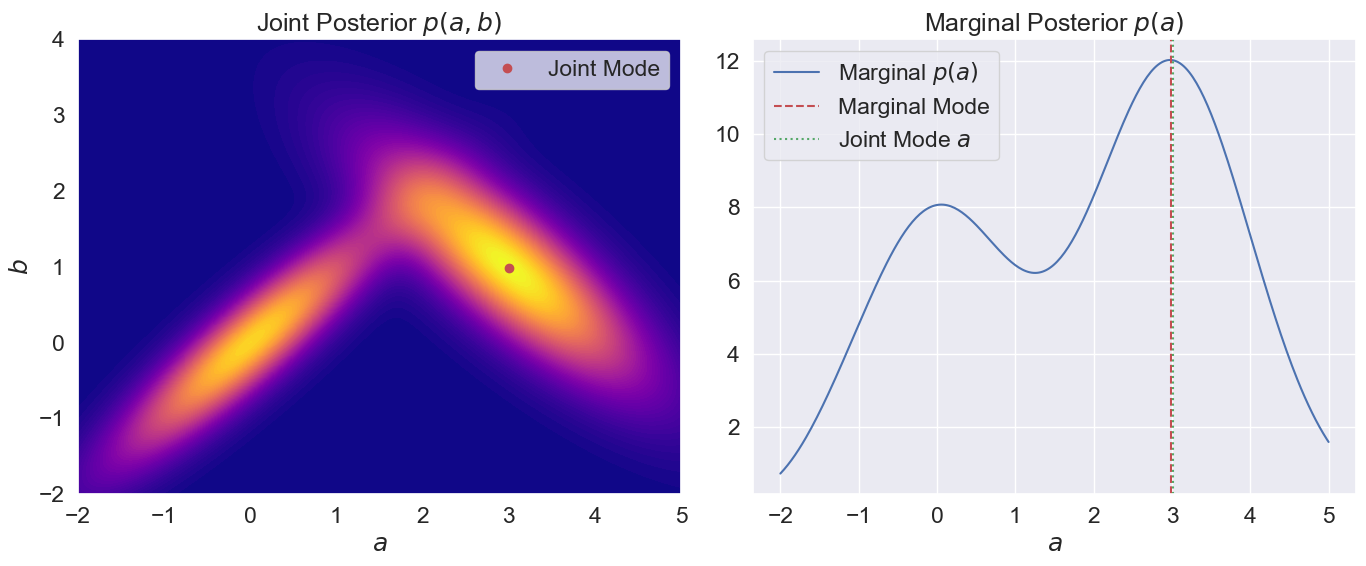

Joint mode of a: 3.0100334448160533
Marginal mode of a: 2.9866220735785953


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define two bivariate Gaussians
mean1 = [0, 0]
cov1 = [[1, 0.9], [0.9, 1]]

mean2 = [3, 1]
cov2 = [[1, -0.8], [-0.8, 1]]

# Mixture weights
w1, w2 = 0.4, 0.6

# Grid
a = np.linspace(-2, 5, 300)
b = np.linspace(-2, 4, 300)
A, B = np.meshgrid(a, b)
pos = np.dstack((A, B))

# Joint density: mixture of Gaussians
rv1 = multivariate_normal(mean1, cov1)
rv2 = multivariate_normal(mean2, cov2)
joint_density = w1 * rv1.pdf(pos) + w2 * rv2.pdf(pos)

# Joint mode (approximate)
joint_mode_idx = np.unravel_index(np.argmax(joint_density), joint_density.shape)
joint_mode_a = A[joint_mode_idx]
joint_mode_b = B[joint_mode_idx]

# Marginal of a
marginal_a = np.sum(joint_density, axis=0)
marginal_mode_a = a[np.argmax(marginal_a)]

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Joint posterior
ax[0].contourf(A, B, joint_density, levels=100, cmap='plasma')
ax[0].plot(joint_mode_a, joint_mode_b, 'ro', label='Joint Mode')
ax[0].set_title('Joint Posterior $p(a, b)$')
ax[0].set_xlabel('$a$')
ax[0].set_ylabel('$b$')
ax[0].legend()

# Marginal posterior of a
ax[1].plot(a, marginal_a, label='Marginal $p(a)$')
ax[1].axvline(marginal_mode_a, color='r', linestyle='--', label='Marginal Mode')
ax[1].axvline(joint_mode_a, color='g', linestyle=':', label='Joint Mode $a$')
ax[1].set_title('Marginal Posterior $p(a)$')
ax[1].set_xlabel('$a$')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Joint mode of a: {joint_mode_a}")
print(f"Marginal mode of a: {marginal_mode_a}")

